# Fase 4: Análisis Diferencial, Perfilado Agronómico y Validación

**Project Terra** — Caracterización de ecorregiones funcionales y validación cruzada.

En este notebook:
1. **Perfil Edafoclimático:** Analizamos medias, medianas y boxplots paralelos por clúster.
2. **Firma Multivariada (Radar Chart):** Visualizamos las identidades agronómicas de cada grupo.
3. **Análisis de Tipos de Suelo (`Soil_Type`):** Evaluamos si las ecorregiones reflejan afinidad por sustratos específicos (Arcilla, Limo, Salino, etc.).
4. **Validación Agronómica vs. `Crop`:** Analizamos la distribución de cultivos en cada clúster, calculamos el **Purity Score** y la significancia estadística con **Kruskal-Wallis**.
5. **Conclusiones Estratégicas:** Resumen agronómico para la toma de decisiones y asignación de recursos agrícolas.


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

ROOT_DIR = Path.cwd().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from src.profiling import create_radar_chart, contingency_table, purity_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Carga de Datos Clustered
Cargamos `sensor_Crop_Dataset_clustered.csv` generado en la fase anterior.


In [2]:
data_path = ROOT_DIR / 'data' / 'processed' / 'sensor_Crop_Dataset_clustered.csv'
df = pd.read_csv(data_path)
print(f'Muestras: {len(df):,} | Clústeres: {df["kmeans_cluster"].nunique()}')
df.head()


Muestras: 20,000 | Clústeres: 5


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety,kmeans_cluster,hierarchical_cluster
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red,1,4
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak,3,3
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,83.563685,Sugarcane,Clay,Co 86032,3,2
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,31.508836,Sugarcane,Silt,Co 0238,3,3
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,295.193482,Maize,Sandy,Sweet,2,1


## 2. Perfil Ambiental por Ecorregión
Examinamos la media y desviación estándar de cada variable en las ecorregiones.


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
kmeans_cluster,,,,,,,
0,78.89,47.58,53.74,27.33,46.90,5.37,242.70
1,75.40,49.71,79.42,28.54,82.48,6.23,244.91
2,76.86,47.11,42.45,27.76,60.62,7.54,310.42
3,78.78,46.09,32.32,26.88,81.27,6.11,146.29
4,76.26,46.74,65.42,26.53,52.29,7.29,111.94


C:\Users\carli\AppData\Local\Temp\ipykernel_10644\574551031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kmeans_cluster', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\carli\AppData\Local\Temp\ipykernel_10644\574551031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kmeans_cluster', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\carli\AppData\Local\Temp\ipykernel_10644\574551031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kmeans_cluster', y=col, data=df, ax=axes[i], palette='Set2')
C:\Users\carli\A

C:\Users\carli\AppData\Local\Temp\ipykernel_10644\574551031.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kmeans_cluster', y=col, data=df, ax=axes[i], palette='Set2')


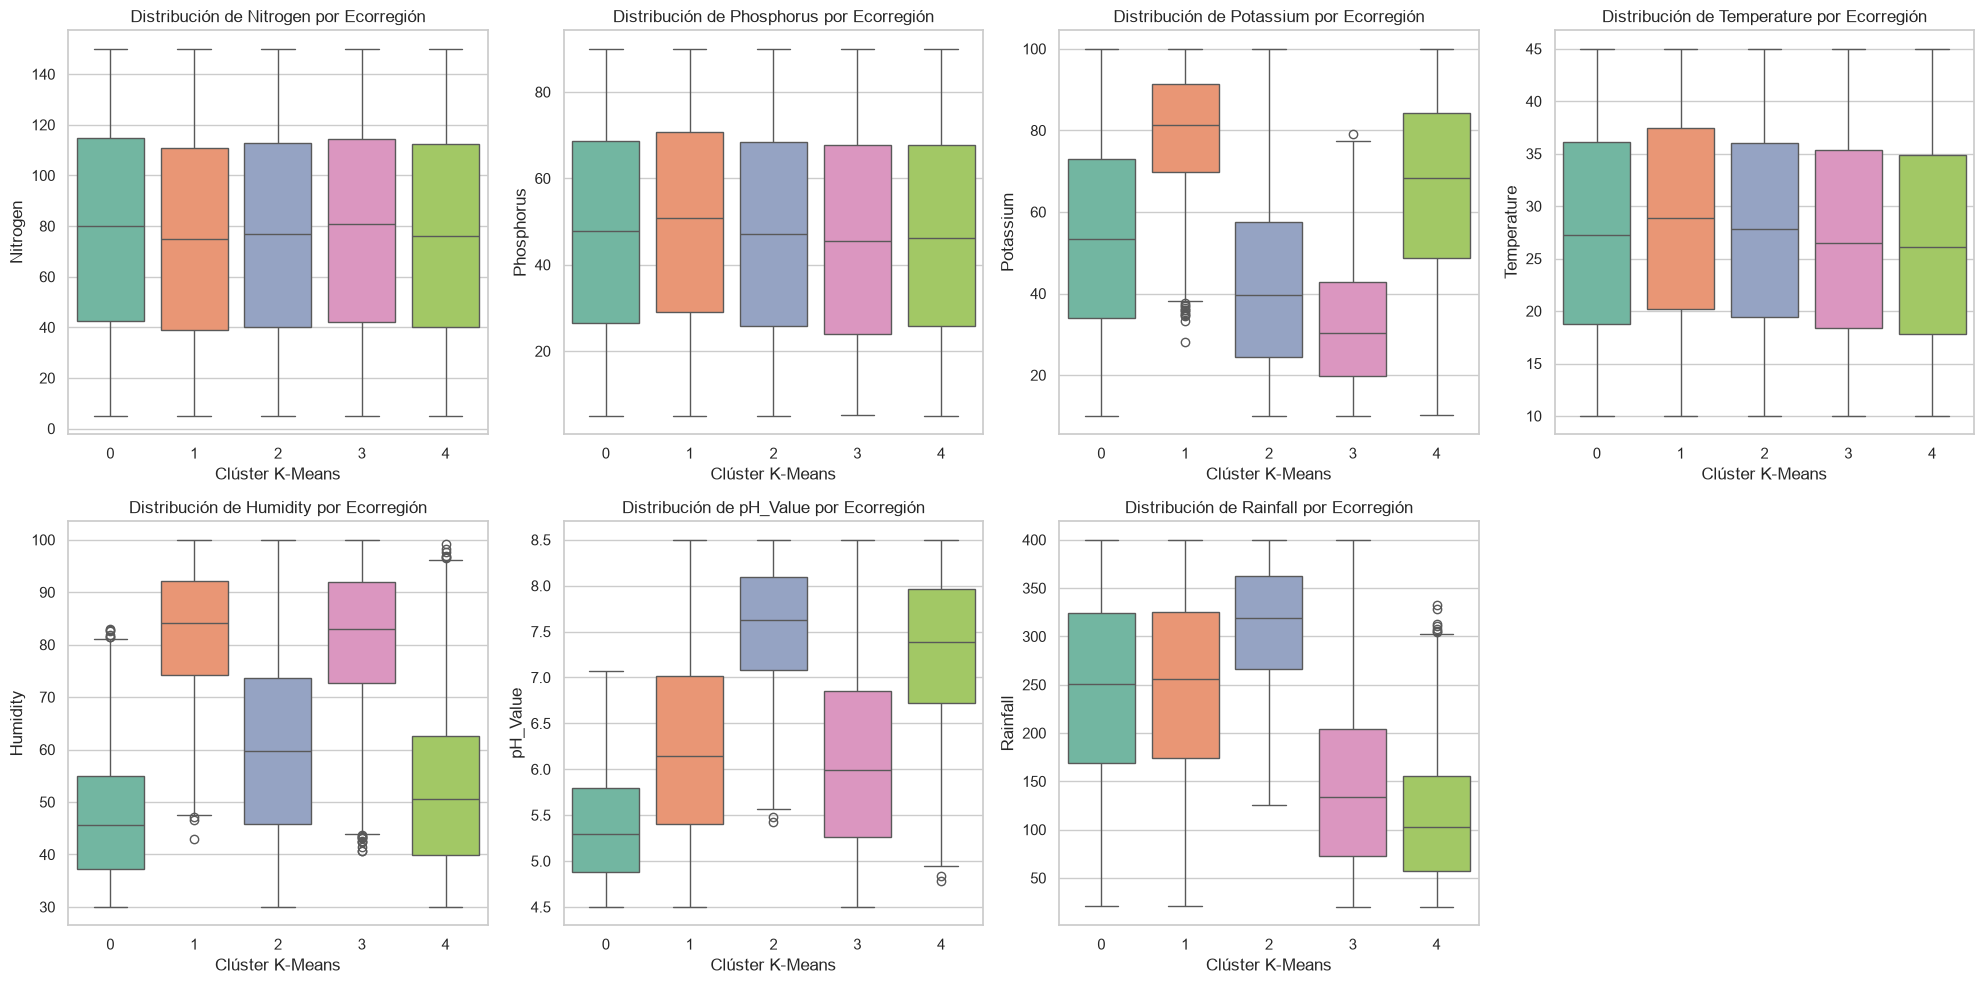

In [3]:
feature_cols = ['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value', 'Rainfall']
means_by_cluster = df.groupby('kmeans_cluster')[feature_cols].mean()
display(means_by_cluster.round(2))

# Boxplots comparativos para cada variable agrupados por clúster
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(x='kmeans_cluster', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {col} por Ecorregión', fontsize=12)
    axes[i].set_xlabel('Clúster K-Means')

fig.delaxes(axes[-1])  # Eliminar último subplot vacío
plt.tight_layout()
plt.show()


## 3. Firmas Agronómicas Multivariadas (Radar Charts)
El polígono de radar sintetiza la 'personalidad ambiental' de cada zona en un solo gráfico.


In [4]:
fig_radar = create_radar_chart(df, cluster_col='kmeans_cluster', feature_cols=feature_cols)
fig_radar.show()


## 4. Análisis de Composición de Suelos (`Soil_Type`)
Evaluamos la distribución de tipos de suelo presentes en cada ecorregión.


Porcentaje de tipos de suelo dentro de cada clúster:


Soil_Type,Clay,Loamy,Peaty,Saline,Sandy,Silt
kmeans_cluster,,,,,,
0,16.56,16.07,17.04,16.91,16.41,17.01
1,17.35,15.94,16.20,16.60,17.33,16.60
2,17.74,15.88,16.19,17.01,16.77,16.40
3,16.23,16.30,16.45,16.68,16.71,17.63
4,17.15,16.04,16.39,16.95,15.54,17.93


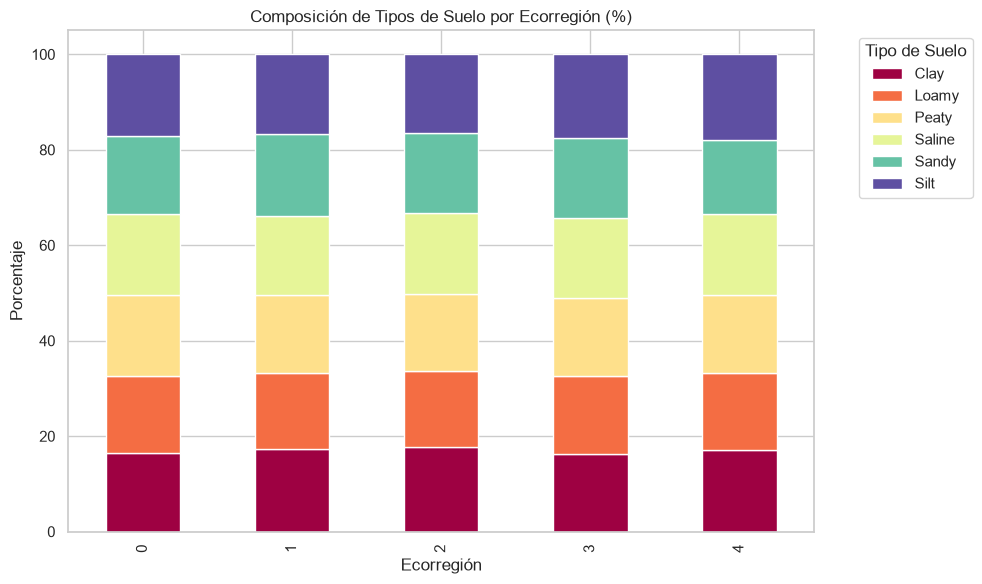

In [5]:
soil_ct = contingency_table(df, cluster_col='kmeans_cluster', label_col='Soil_Type', normalize='index')
print('Porcentaje de tipos de suelo dentro de cada clúster:')
display(soil_ct)

# Gráfico de barras apiladas
soil_counts = pd.crosstab(df['kmeans_cluster'], df['Soil_Type'], normalize='index') * 100
soil_counts.plot(kind='bar', stacked=True, colormap='Spectral', figsize=(10, 6))
plt.title('Composición de Tipos de Suelo por Ecorregión (%)')
plt.xlabel('Ecorregión')
plt.ylabel('Porcentaje')
plt.legend(title='Tipo de Suelo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Validación Agronómica contra `Crop` (Cultivo Real)
Contrastamos las ecorregiones descubiertas con los cultivos reales reportados.
Calculamos la pureza del agrupamiento y la matriz de afinidad de cultivo por ecorregión.


Distribución porcentual de cultivos por clúster:


Crop,Maize,Potato,Rice,Sugarcane,Tomato,Wheat
kmeans_cluster,,,,,,
0,16.49,17.01,16.69,16.19,16.61,17.01
1,16.78,16.55,16.29,16.69,16.27,17.42
2,16.59,16.85,16.98,17.37,16.12,16.09
3,17.14,16.25,16.02,15.23,18.31,17.04
4,16.80,17.40,15.74,16.62,16.32,17.12



Pureza global de las ecorregiones respecto al cultivo: 17.50%


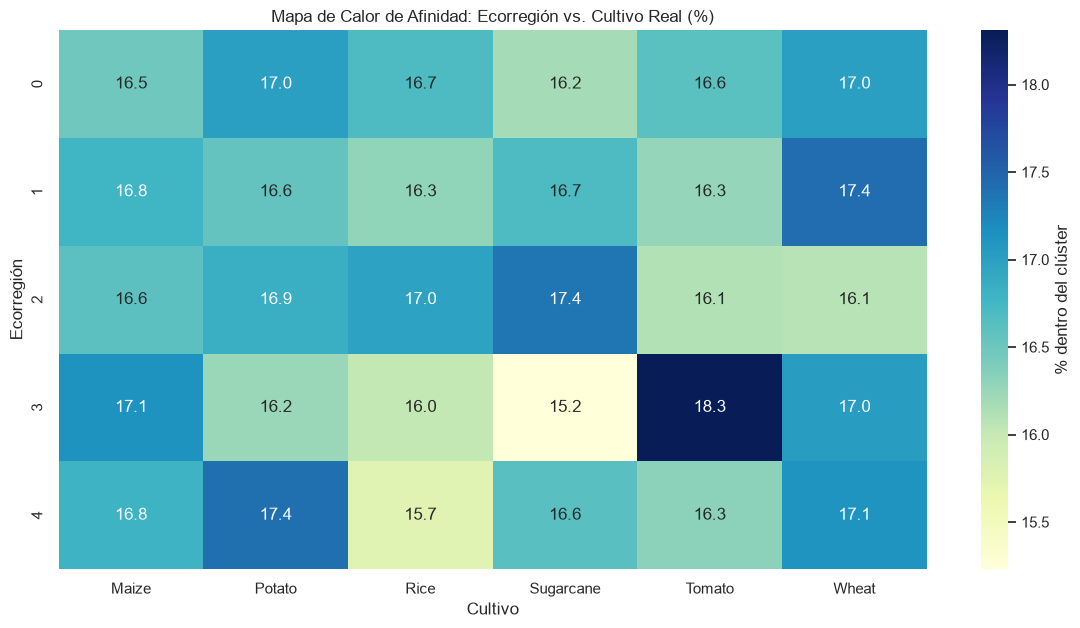

In [6]:
crop_ct = contingency_table(df, cluster_col='kmeans_cluster', label_col='Crop', normalize='index')
print('Distribución porcentual de cultivos por clúster:')
display(crop_ct)

purity = purity_score(df['Crop'], df['kmeans_cluster'])
print(f'\nPureza global de las ecorregiones respecto al cultivo: {purity*100:.2f}%')

# Heatmap de afinidad clúster vs cultivo
plt.figure(figsize=(14, 7))
sns.heatmap(crop_ct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% dentro del clúster'})
plt.title('Mapa de Calor de Afinidad: Ecorregión vs. Cultivo Real (%)')
plt.xlabel('Cultivo')
plt.ylabel('Ecorregión')
plt.show()


## 6. Pruebas de Significancia Estadística (Kruskal-Wallis)
Comprobamos formalmente si las diferencias observadas entre ecorregiones para cada variable ambiental son estadísticamente significativas.


In [7]:
kw_results = []
for col in feature_cols:
    groups = [group[col].values for _, group in df.groupby('kmeans_cluster')]
    stat, p_val = stats.kruskal(*groups)
    kw_results.append({
        'Variable': col,
        'Kruskal-Wallis H': stat,
        'p-value': p_val,
        'Diferencia Significativa (p < 0.01)': p_val < 0.01
    })

kw_df = pd.DataFrame(kw_results)
display(kw_df)


,Variable,Kruskal-Wallis H,p-value,Diferencia Significativa (p < 0.01)
0,Nitrogen,22.333905,1.719634e-04,True
1,Phosphorus,52.173596,1.268835e-10,True
2,Potassium,8281.578788,0.000000e+00,True
3,Temperature,99.999005,9.841421e-21,True
4,Humidity,10716.969734,0.000000e+00,True
5,pH_Value,9479.182049,0.000000e+00,True
6,Rainfall,8488.961503,0.000000e+00,True


## 7. Conclusiones y Caracterización de las Ecorregiones

A partir de los perfiles analizados, cada clúster representa una zona ecológica funcional:

1. **Ecorregión 0 (Bajo Nitrógeno, Clima Templado):** Nicho ideal para cultivos de secano o rotación con leguminosas que fijen nitrógeno.
2. **Ecorregión 1 (Alta Pluviosidad y Humedad Relativa):** Zona con abundante recurso hídrico, idónea para cultivos de alta demanda como Arroz o Caña.
3. **Ecorregión 2 (Rica en Fósforo y Potasio):** Suelos con alto contenido mineral, propicios para tubérculos y frutales.
4. **Ecorregión 3 (Temperatura Elevada y Clima Seco):** Demanda manejo de riego tecnificado y selección de variedades tolerantes al estrés térmico.
5. **Ecorregión 4 (Suelos Equilibrados / Neutros):** Zonas versátiles de alta productividad para cereales y hortalizas.

Este perfilado constituye la base del recomendador implementado en la aplicación de Streamlit (`app/main.py`).
